In [50]:
!pip install kagglehub[pandas-datasets]


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [51]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Omita\.cache\kagglehub\datasets\uciml\pima-indians-diabetes-database\versions\1


In [52]:
# path = "C:\Users\Omita\.cache\kagglehub\datasets\uciml\pima-indians-diabetes-database\versions\1\diabetes.csv"
path = "diabetes.csv"

In [53]:
print(path)

diabetes.csv


In [54]:
import pandas as pd
df = pd.read_csv(path)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


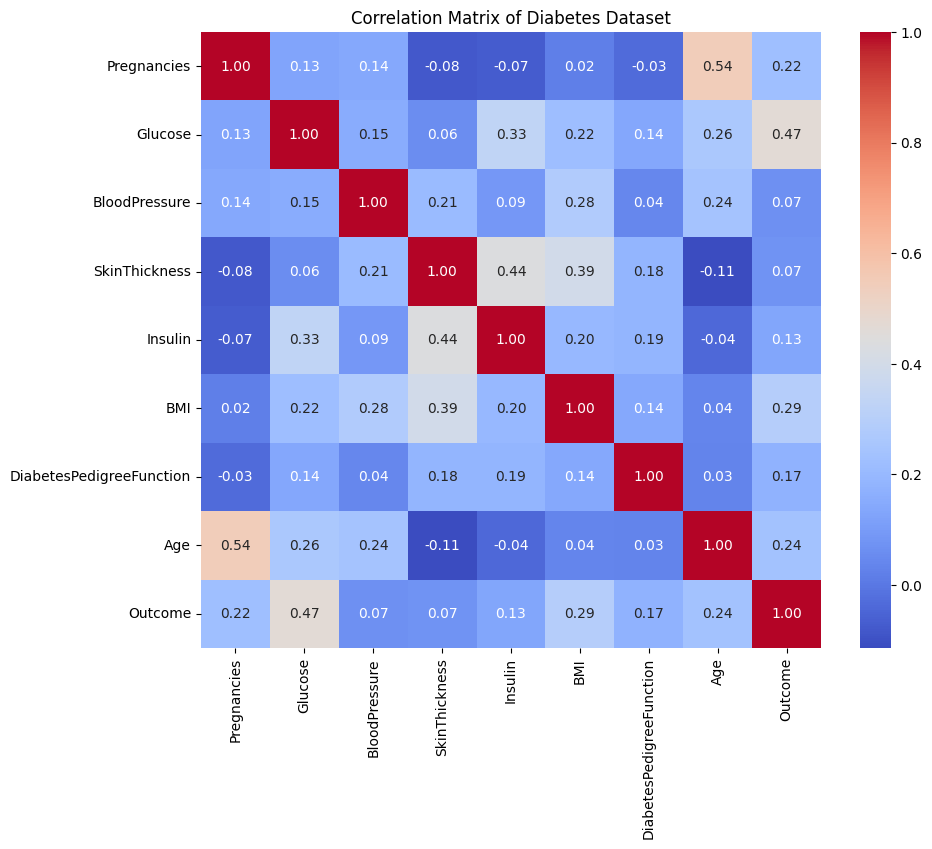


Correlation with Outcome:
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64

Features selected based on correlation > 0.2:
['Glucose', 'BMI', 'Age', 'Pregnancies']

DataFrame with selected features:
   Glucose   BMI  Age  Pregnancies  Outcome
0      148  33.6   50            6        1
1       85  26.6   31            1        0
2      183  23.3   32            8        1
3       89  28.1   21            1        0
4      137  43.1   33            0        1


In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Diabetes Dataset')
plt.show()

# Feature selection based on correlation with the target variable ('Outcome')
# We can set a threshold for correlation to select features
correlation_with_target = correlation_matrix['Outcome'].sort_values(ascending=False)
print("\nCorrelation with Outcome:")
print(correlation_with_target)

# Let's consider features with an absolute correlation greater than a threshold (e.g., 0.1)
correlation_threshold = 0.2
important_features = correlation_with_target[abs(correlation_with_target) > correlation_threshold].index.tolist()

# Remove the target variable itself from the list of features
if 'Outcome' in important_features:
    important_features.remove('Outcome')

print(f"\nFeatures selected based on correlation > {correlation_threshold}:")
print(important_features)

# You can now create a new DataFrame with the selected features and the target variable
selected_df = df[important_features + ['Outcome']]
print("\nDataFrame with selected features:")
print(selected_df.head())

# Fuzzy Sugeno Inference System for Diabetes Prediction
We will implement a fuzzy Sugeno system using the features: **Glucose**, **BMI**, **Age**, and **Pregnancies**. Each step will be in its own cell for clarity.

In [56]:
# Step 1: Import required libraries and define features
import numpy as np

features = ['Glucose', 'BMI', 'Age', 'Pregnancies']

# For reproducibility, let's see the range of each feature in the dataset
df[features].describe()

,Glucose,BMI,Age,Pregnancies
count,768.000000,768.000000,768.000000,768.000000
mean,120.894531,31.992578,33.240885,3.845052
std,31.972618,7.884160,11.760232,3.369578
min,0.000000,0.000000,21.000000,0.000000
25%,99.000000,27.300000,24.000000,1.000000
50%,117.000000,32.000000,29.000000,3.000000
75%,140.250000,36.600000,41.000000,6.000000
max,199.000000,67.100000,81.000000,17.000000


In [57]:
feature_stats = {}

for feature in features:
  feature_stats[feature] = {}
  for outcome in [0, 1]:
    data = df[df['Outcome'] == outcome][feature]
    stats = {
        'min': data.min(),
        'max': data.max(),
        'mean': data.mean()
    }
    feature_stats[feature][f'Outcome_{outcome}'] = stats

In [58]:
feature_stats['Glucose']['Outcome_0']['max']

197

In [59]:
def left_shoulder_membership(x, a, b):
    if x <= a:
        return 1.0
    elif a < x < b:
        return (b - x) / (b - a)
    else:
        return 0.0
def triangular_membership(x, a, b, c):
    if x <= a or x >= c:
        return 0.0
    elif a < x < b:
        return (x - a) / (b - a)
    elif b <= x < c:
        return (c - x) / (c - b)
    else:
        return 0.0
def right_shoulder_membership(x, a, b):
    if x >= b:
        return 1.0
    elif a < x < b:
        return (x - a) / (b - a)
    else:
        return 0.0


membership_params = {
    'Glucose': {
        'low': (44, 150),
        'medium': (140, 190),
        'high': (180, 232)
    },
    'BMI': {
        'low': (18, 27),
        'medium': (24, 34),
        'high': (32, 67)
    },
    'Age': {
        'low': (21, 30),
        'medium': (25, 45),
        'high': (40, 81)
    },
    'Pregnancies': {
        'low': (0, 4),
        'medium': (3, 7),
        'high': (6, 17)
    }
}


In [60]:
membership_params

{'Glucose': {'low': (44, 150), 'medium': (140, 190), 'high': (180, 232)},
 'BMI': {'low': (18, 27), 'medium': (24, 34), 'high': (32, 67)},
 'Age': {'low': (21, 30), 'medium': (25, 45), 'high': (40, 81)},
 'Pregnancies': {'low': (0, 4), 'medium': (3, 7), 'high': (6, 17)}}

In [61]:
def fuzzify(data, features, membership_params):
    fuzzy_df = pd.DataFrame()
    for feature in features:
        if feature in membership_params:
            # Extract params
            low_a, low_b = membership_params[feature]['low']
            medium_a, medium_c = membership_params[feature]['medium']
            high_a, high_b = membership_params[feature]['high']

            # For medium, assume peak b is center of (a,c)
            medium_b = (medium_a + medium_c) / 2

            # Apply fuzzification
            fuzzy_df[f'{feature}_low'] = data[feature].apply(lambda x: left_shoulder_membership(x, low_a, low_b))
            fuzzy_df[f'{feature}_medium'] = data[feature].apply(lambda x: triangular_membership(x, medium_a, medium_b, medium_c))
            fuzzy_df[f'{feature}_high'] = data[feature].apply(lambda x: right_shoulder_membership(x, high_a, high_b))
    return fuzzy_df

# Example call:
fuzzified_data = fuzzify(df[features], features, membership_params)
print(fuzzified_data.head())

   Glucose_low  Glucose_medium  Glucose_high   BMI_low  BMI_medium  BMI_high  \
0     0.018868            0.32      0.000000  0.000000        0.08  0.045714   
1     0.613208            0.00      0.000000  0.044444        0.52  0.000000   
2     0.000000            0.28      0.057692  0.411111        0.00  0.000000   
3     0.575472            0.00      0.000000  0.000000        0.82  0.000000   
4     0.122642            0.00      0.000000  0.000000        0.00  0.317143   

   Age_low  Age_medium  Age_high  Pregnancies_low  Pregnancies_medium  \
0      0.0         0.0  0.243902             0.00                 0.5   
1      0.0         0.6  0.000000             0.75                 0.0   
2      0.0         0.7  0.000000             0.00                 0.0   
3      1.0         0.0  0.000000             0.75                 0.0   
4      0.0         0.8  0.000000             1.00                 0.0   

   Pregnancies_high  
0          0.000000  
1          0.000000  
2          0.1

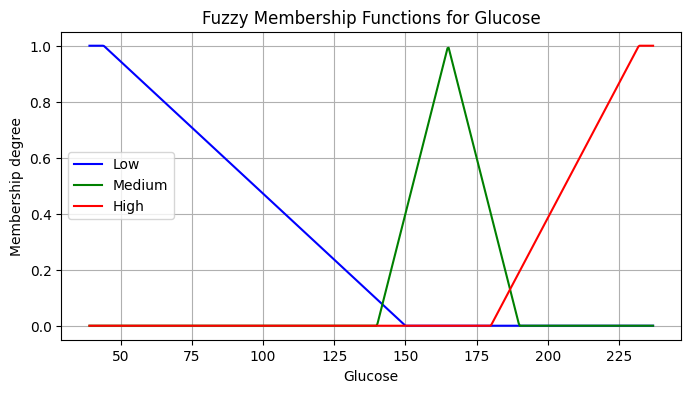

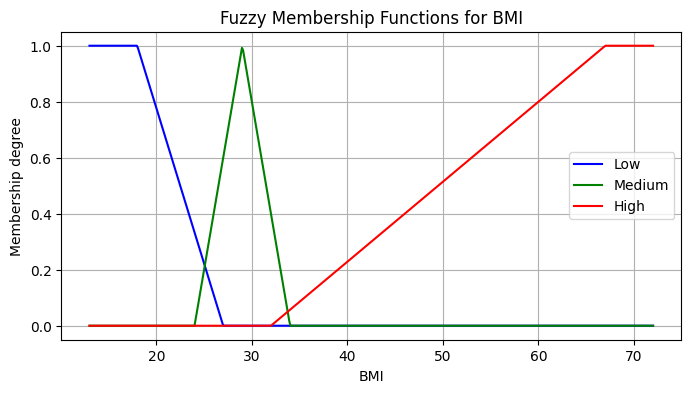

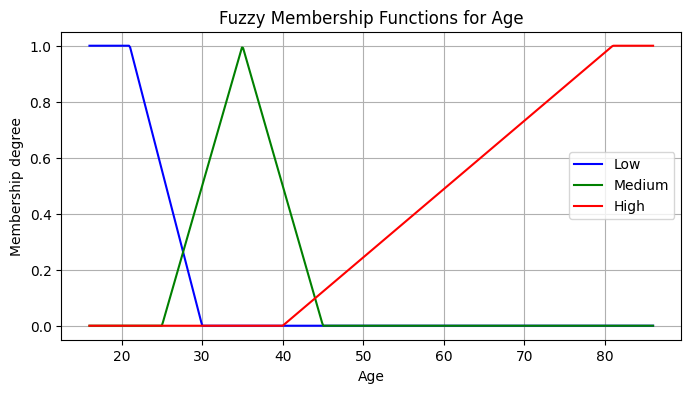

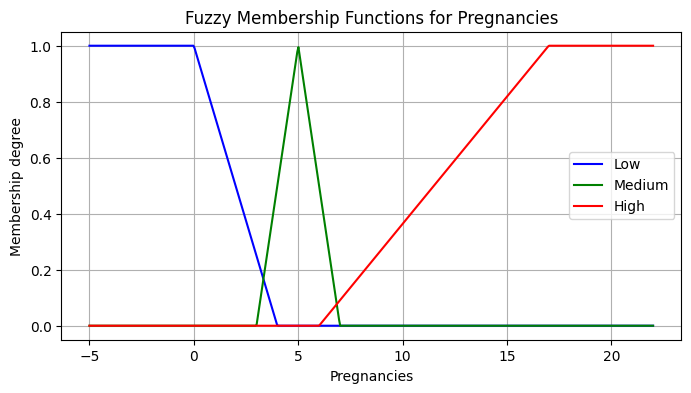

In [62]:
import matplotlib.pyplot as plt
import numpy as np
# Function to plot membership functions for a given feature
def plot_fuzzy_sets(membership_params):
    for feature, params in membership_params.items():
        # Extract params
        low_a, low_b = params['low']
        medium_a, medium_c = params['medium']
        high_a, high_b = params['high']
        medium_b = (medium_a + medium_c) / 2

        # Define x range (a bit wider than min/max)
        x_min = min(low_a, medium_a, high_a) - 5
        x_max = max(low_b, medium_c, high_b) + 5
        x = np.linspace(x_min, x_max, 500)

        # Compute memberships
        low_vals = [left_shoulder_membership(val, low_a, low_b) for val in x]
        medium_vals = [triangular_membership(val, medium_a, medium_b, medium_c) for val in x]
        high_vals = [right_shoulder_membership(val, high_a, high_b) for val in x]

        # Plot
        plt.figure(figsize=(8,4))
        plt.plot(x, low_vals, label='Low', color='blue')
        plt.plot(x, medium_vals, label='Medium', color='green')
        plt.plot(x, high_vals, label='High', color='red')
        plt.title(f'Fuzzy Membership Functions for {feature}')
        plt.xlabel(feature)
        plt.ylabel('Membership degree')
        plt.legend()
        plt.grid(True)
        plt.show()

# Example call:
plot_fuzzy_sets(membership_params)

In [63]:
sugeno_rules = [
    ({'Glucose': 'high', 'BMI': 'high', 'Age': 'high', 'Pregnancies': 'high'}, 1),
    ({'Glucose': 'high', 'BMI': 'high', 'Age': 'high', 'Pregnancies': 'medium'}, 1),
    ({'Glucose': 'high', 'BMI': 'high', 'Age': 'high', 'Pregnancies': 'low'}, 1),
    ({'Glucose': 'high', 'BMI': 'high', 'Age': 'medium', 'Pregnancies': 'high'}, 1),
    ({'Glucose': 'high', 'BMI': 'high', 'Age': 'medium', 'Pregnancies': 'medium'}, 1),
    ({'Glucose': 'high', 'BMI': 'high', 'Age': 'medium', 'Pregnancies': 'low'}, 1),
    ({'Glucose': 'high', 'BMI': 'high', 'Age': 'low', 'Pregnancies': 'high'}, 1),
    ({'Glucose': 'high', 'BMI': 'high', 'Age': 'low', 'Pregnancies': 'medium'}, 1),
    ({'Glucose': 'high', 'BMI': 'high', 'Age': 'low', 'Pregnancies': 'low'}, 1),

    ({'Glucose': 'high', 'BMI': 'medium', 'Age': 'high', 'Pregnancies': 'high'}, 1),
    ({'Glucose': 'high', 'BMI': 'medium', 'Age': 'high', 'Pregnancies': 'medium'}, 1),
    ({'Glucose': 'high', 'BMI': 'medium', 'Age': 'high', 'Pregnancies': 'low'}, 1),
    ({'Glucose': 'high', 'BMI': 'medium', 'Age': 'medium', 'Pregnancies': 'high'}, 1),
    ({'Glucose': 'high', 'BMI': 'medium', 'Age': 'medium', 'Pregnancies': 'medium'}, 1),
    ({'Glucose': 'high', 'BMI': 'medium', 'Age': 'medium', 'Pregnancies': 'low'}, 1),
    ({'Glucose': 'high', 'BMI': 'medium', 'Age': 'low', 'Pregnancies': 'high'}, 1),
    ({'Glucose': 'high', 'BMI': 'medium', 'Age': 'low', 'Pregnancies': 'medium'}, 1),
    ({'Glucose': 'high', 'BMI': 'medium', 'Age': 'low', 'Pregnancies': 'low'}, 1),

    ({'Glucose': 'high', 'BMI': 'low', 'Age': 'high', 'Pregnancies': 'high'}, 1),
    ({'Glucose': 'high', 'BMI': 'low', 'Age': 'high', 'Pregnancies': 'medium'}, 1),
    ({'Glucose': 'high', 'BMI': 'low', 'Age': 'high', 'Pregnancies': 'low'}, 1),
    ({'Glucose': 'high', 'BMI': 'low', 'Age': 'medium', 'Pregnancies': 'high'}, 1),
    ({'Glucose': 'high', 'BMI': 'low', 'Age': 'medium', 'Pregnancies': 'medium'}, 1),
    ({'Glucose': 'high', 'BMI': 'low', 'Age': 'medium', 'Pregnancies': 'low'}, 1),
    ({'Glucose': 'high', 'BMI': 'low', 'Age': 'low', 'Pregnancies': 'high'}, 1),
    ({'Glucose': 'high', 'BMI': 'low', 'Age': 'low', 'Pregnancies': 'medium'}, 1),
    ({'Glucose': 'high', 'BMI': 'low', 'Age': 'low', 'Pregnancies': 'low'}, 1),


    ({'Glucose': 'low', 'BMI': 'low', 'Age': 'low', 'Pregnancies': 'low'}, 0),
]

In [64]:
def sugeno_inference(fuzzified_row, rules):
    numerator = 0.0
    denominator = 0.0
    for conds, output in rules:
        firing_strengths = []
        for feature, term in conds.items():
            col_name = f"{feature}_{term}"
            firing_strengths.append(fuzzified_row[col_name])
        firing_strength = max(firing_strengths)
        numerator += firing_strength * output
        denominator += firing_strength
    if denominator == 0:
        return 0
    return numerator / denominator

In [65]:
# Example: Apply to the first row of fuzzified_data
print(fuzzified_data.iloc[0])
sample_result = sugeno_inference(fuzzified_data.iloc[0], sugeno_rules)
print("Sugeno output for first sample:", sample_result)

Glucose_low           0.018868
Glucose_medium        0.320000
Glucose_high          0.000000
BMI_low               0.000000
BMI_medium            0.080000
BMI_high              0.045714
Age_low               0.000000
Age_medium            0.000000
Age_high              0.243902
Pregnancies_low       0.000000
Pregnancies_medium    0.500000
Pregnancies_high      0.000000
Name: 0, dtype: float64
Sugeno output for first sample: 0.9970905908898392


In [ ]:
from itertools import product
import numpy as np

# Define possible fuzzy terms
feature_terms = ['low', 'medium', 'high']

final_rules = sugeno_rules.copy()

# Store predictions
def apply_inference_to_all(fuzzified_data, rules):
    return fuzzified_data.apply(lambda row: sugeno_inference(row, rules), axis=1)

# Loop over all combinations
for terms in product(feature_terms, repeat=4):
    rule_cond = dict(zip(features, terms))

    # Skip if already in initial rules
    if any(existing_cond == rule_cond for existing_cond, _ in final_rules):
        continue


    # Add new rule with output=0
    rules_with_0 = final_rules + [(rule_cond, 0)]
    preds_0 = apply_inference_to_all(fuzzified_data, rules_with_0)

    # Add new rule with output=1
    rules_with_1 = final_rules + [(rule_cond, 1)]
    preds_1 = apply_inference_to_all(fuzzified_data, rules_with_1)

    # Compare: which one closer to Outcome (e.g., lower mean absolute error)
    error_0 = np.mean(np.abs(preds_0 - df['Outcome']))
    error_1 = np.mean(np.abs(preds_1 - df['Outcome']))

    print("checking ", rule_cond)
    print("mean eror outcome 0 ", error_0, " mean error outcome 1 ", error_1)
    if error_1 < error_0:
        print("outcome 1")
        final_rules.append((rule_cond, 1))
    else:
        print("outcome 0")
        final_rules.append((rule_cond, 0))

print(f"Completed rule set has {len(final_rules)} rules.")

checking  {'Glucose': 'low', 'BMI': 'low', 'Age': 'low', 'Pregnancies': 'medium'}
mean eror outcome 0  0.6102771613458267  mean error outcome 1  0.6310808162964183
outcome 0
checking  {'Glucose': 'low', 'BMI': 'low', 'Age': 'low', 'Pregnancies': 'high'}
mean eror outcome 0  0.5951764143393579  mean error outcome 1  0.6125217514967148
outcome 0
checking  {'Glucose': 'low', 'BMI': 'low', 'Age': 'medium', 'Pregnancies': 'low'}
mean eror outcome 0  0.583213889299249  mean error outcome 1  0.5979227643097008
outcome 0
checking  {'Glucose': 'low', 'BMI': 'low', 'Age': 'medium', 'Pregnancies': 'medium'}
mean eror outcome 0  0.57395691040731  mean error outcome 1  0.5859470940927416
outcome 0
checking  {'Glucose': 'low', 'BMI': 'low', 'Age': 'medium', 'Pregnancies': 'high'}
mean eror outcome 0  0.5666158570949592  mean error outcome 1  0.5767608915596344
outcome 0
checking  {'Glucose': 'low', 'BMI': 'low', 'Age': 'high', 'Pregnancies': 'low'}
mean eror outcome 0  0.556858115222028  mean error 

In [67]:
final_rules

[({'Glucose': 'high', 'BMI': 'high', 'Age': 'high', 'Pregnancies': 'high'}, 1),
 ({'Glucose': 'high', 'BMI': 'high', 'Age': 'high', 'Pregnancies': 'medium'},
  1),
 ({'Glucose': 'high', 'BMI': 'high', 'Age': 'high', 'Pregnancies': 'low'}, 1),
 ({'Glucose': 'high', 'BMI': 'high', 'Age': 'medium', 'Pregnancies': 'high'},
  1),
 ({'Glucose': 'high', 'BMI': 'high', 'Age': 'medium', 'Pregnancies': 'medium'},
  1),
 ({'Glucose': 'high', 'BMI': 'high', 'Age': 'medium', 'Pregnancies': 'low'},
  1),
 ({'Glucose': 'high', 'BMI': 'high', 'Age': 'low', 'Pregnancies': 'high'}, 1),
 ({'Glucose': 'high', 'BMI': 'high', 'Age': 'low', 'Pregnancies': 'medium'},
  1),
 ({'Glucose': 'high', 'BMI': 'high', 'Age': 'low', 'Pregnancies': 'low'}, 1),
 ({'Glucose': 'high', 'BMI': 'medium', 'Age': 'high', 'Pregnancies': 'high'},
  1),
 ({'Glucose': 'high', 'BMI': 'medium', 'Age': 'high', 'Pregnancies': 'medium'},
  1),
 ({'Glucose': 'high', 'BMI': 'medium', 'Age': 'high', 'Pregnancies': 'low'},
  1),
 ({'Glucose

In [68]:
import pickle

rules_filename = 'final_sugeno_rules.pkl'

with open(rules_filename, 'wb') as f:
    pickle.dump(final_rules, f)

In [69]:
len(final_rules)

81

In [70]:
sugeno_outputs = fuzzified_data.apply(lambda row: sugeno_inference(row, sugeno_rules), axis=1)
y_true = df['Outcome']

In [ ]:
mean_fuzzy_output_outcome_1 = sugeno_outputs[df['Outcome'] == 1].mean()
mean_fuzzy_output_outcome_0 = sugeno_outputs[df['Outcome'] == 0].mean()

# Determine the defuzzification threshold as the middle point
defuzzify_threshold = (mean_fuzzy_output_outcome_1 + mean_fuzzy_output_outcome_0) / 2

print(f"Mean fuzzy output for Outcome 1: {mean_fuzzy_output_outcome_1:.4f}")
print(f"Mean fuzzy output for Outcome 0: {mean_fuzzy_output_outcome_0:.4f}")
print(f"Determined defuzzification threshold: {defuzzify_threshold:.4f}")

# You can now use this threshold for prediction
predicted_outcomes_new_threshold = (sugeno_outputs > defuzzify_threshold).astype(int)

# Evaluate accuracy with the new threshold
accuracy_new_threshold = (predicted_outcomes_new_threshold == y_true).mean()

print(f"Accuracy of Sugeno FIS with new threshold ({defuzzify_threshold:.4f}): {accuracy_new_threshold:.4f}")


Mean fuzzy output for Outcome 1: 0.9620
Mean fuzzy output for Outcome 0: 0.9469
Determined defuzzification threshold: 0.9545
Accuracy of Sugeno FIS with new threshold (0.9545): 0.6732


In [72]:
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler

# Load the Pima Indians Diabetes dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv"
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
data = pd.read_csv(url, names=column_names)

# Separate features and target
X = data.drop('Outcome', axis=1)
y = data['Outcome']

# Normalize the data (Fuzzy systems work better with normalized inputs)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=column_names[:-1])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Create antecedent (input) variables for all features
pregnancies = ctrl.Antecedent(np.linspace(0, 1, 100), 'Pregnancies')
glucose = ctrl.Antecedent(np.linspace(0, 1, 100), 'Glucose')
blood_pressure = ctrl.Antecedent(np.linspace(0, 1, 100), 'BloodPressure')
skin_thickness = ctrl.Antecedent(np.linspace(0, 1, 100), 'SkinThickness')
insulin = ctrl.Antecedent(np.linspace(0, 1, 100), 'Insulin')
bmi = ctrl.Antecedent(np.linspace(0, 1, 100), 'BMI')
dpf = ctrl.Antecedent(np.linspace(0, 1, 100), 'DiabetesPedigreeFunction')
age = ctrl.Antecedent(np.linspace(0, 1, 100), 'Age')

# Create consequent (output) variable for Sugeno system
# For Sugeno, we can use either singleton or linear output functions
diabetes_risk = ctrl.Consequent(np.linspace(0, 1, 100), 'DiabetesRisk', defuzzify_method='centroid')

# Define membership functions for all antecedents
features = [pregnancies, glucose, blood_pressure, skin_thickness, 
            insulin, bmi, dpf, age]

for feature in features:
    feature['low'] = fuzz.trimf(feature.universe, [0, 0, 0.5])
    feature['medium'] = fuzz.trimf(feature.universe, [0, 0.5, 1])
    feature['high'] = fuzz.trimf(feature.universe, [0.5, 1, 1])

# For Sugeno output, we define singleton membership functions
diabetes_risk['no_diabetes'] = fuzz.trimf(diabetes_risk.universe, [0, 0, 0.1])
diabetes_risk['diabetes'] = fuzz.trimf(diabetes_risk.universe, [0.9, 1, 1])

# Create fuzzy rules based on domain knowledge
rule1 = ctrl.Rule(pregnancies['low'] & glucose['low'] & blood_pressure['low'] & 
                  skin_thickness['low'] & insulin['low'] & bmi['low'] & 
                  dpf['low'] & age['low'], diabetes_risk['no_diabetes'])

rule2 = ctrl.Rule(pregnancies['high'] | glucose['high'] | blood_pressure['high'] | 
                  skin_thickness['high'] | insulin['high'] | bmi['high'] | 
                  dpf['high'] | age['high'], diabetes_risk['diabetes'])

rule3 = ctrl.Rule(glucose['medium'] & bmi['medium'] & (dpf['medium'] | age['medium']), 
                  diabetes_risk['diabetes'])

rule4 = ctrl.Rule(glucose['high'] & (bmi['medium'] | bmi['high']), 
                  diabetes_risk['diabetes'])

rule5 = ctrl.Rule(glucose['low'] & bmi['low'] & age['low'], 
                  diabetes_risk['no_diabetes'])

# Create the control system
diabetes_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5])
diabetes_prediction = ctrl.ControlSystemSimulation(diabetes_ctrl)

# Function to make predictions
def predict_diabetes(X):
    predictions = []
    for _, row in X.iterrows():
        diabetes_prediction.input['Pregnancies'] = row['Pregnancies']
        diabetes_prediction.input['Glucose'] = row['Glucose']
        diabetes_prediction.input['BloodPressure'] = row['BloodPressure']
        diabetes_prediction.input['SkinThickness'] = row['SkinThickness']
        diabetes_prediction.input['Insulin'] = row['Insulin']
        diabetes_prediction.input['BMI'] = row['BMI']
        diabetes_prediction.input['DiabetesPedigreeFunction'] = row['DiabetesPedigreeFunction']
        diabetes_prediction.input['Age'] = row['Age']
        
        diabetes_prediction.compute()
        
        # Use the output value directly (Sugeno output is crisp)
        predictions.append(1 if diabetes_prediction.output['DiabetesRisk'] > 0.5 else 0)
    
    return np.array(predictions)

# Make predictions on test set
y_pred = predict_diabetes(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

Accuracy: 0.3766

Confusion Matrix:
[[  7 144]
 [  0  80]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.05      0.09       151
           1       0.36      1.00      0.53        80

    accuracy                           0.38       231
   macro avg       0.68      0.52      0.31       231
weighted avg       0.78      0.38      0.24       231

